# Micrograd by Andrej Karpathy


#### What is Derivative ?


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline


In [2]:
def f(x):
    return 3*x**2 - 4*x  + 5

In [3]:
f(3.0)

20.0

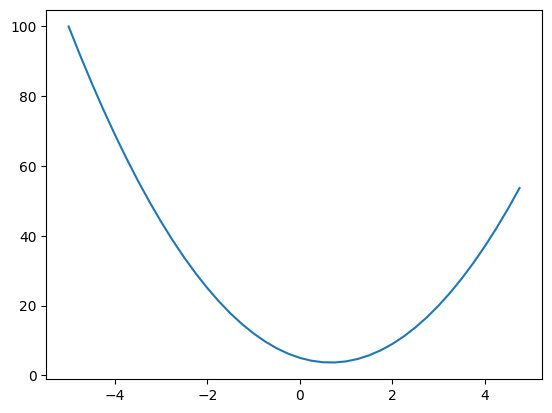

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

> The dervative is how much the constant that you add to your function will change your output in final will it increase or decrease.

In [5]:
# example
h = 0.001
x = 3.0
print(f" this is how much the function responded: {f(x+h)} ")
print(f"This is the difference of adding h to x: {f(x+h)-f(x)}")
print(f" Slope: {(f(x+h)-f(x))/h}")

 this is how much the function responded: 20.014003000000002 
This is the difference of adding h to x: 0.01400300000000243
 Slope: 14.00300000000243


In [6]:
# more complex
h= 0.001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
a += h
d2 = a*b + c
print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.997
slope -3.0000000000001137


> Tricky part here, if a is added the d2 decreases because a = 2.001 and b = -3.0 since positive increased that means the c gets to subtract less
But when B is added with h then its oppositive because the c gets to subtract more.
if c is added with h then d1 and d2 are almost same because c is greater number

## Building Value Class

In [7]:
class Value:
    def __init__(self,data, _children=() , _op = '', label = ''):  # children is tuple using for efficiency on greater calcs this gives previous values, _op will give us what operation was used to create the value
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value:(data = {self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out =  Value(self.data + other.data , (self, other) , '+')
        def _backward():
            self.grad += 1.0 * out.grad # we add and why 1.0 because of derivative of additon and multivarse Chain formula
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    def __radd__(self, other):
        return self + other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self,other):
        return self + (-other)
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out =  Value(self.data * other.data , (self,other) , '*')
        def _backward():
            self.grad += other.data * out.grad # we add and why 1.0 because of derivative of additon and multivarse Chain formula
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self,other): # other * self 
        return self * other
    
    def __truediv__(self, other): # a/b = a*b**-1
        return self * other**-1
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x)+1)  # Hyperbolic function for tanh(x) = e^2x - 1 / e^2x + 1
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad += (1-t**2) * out.grad  # derivative of tanh(x) = 1-sq(tanhx) and multiply the out.grad (i.e basically 1.0)
        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,) , 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int,float)), "Supporting only int and float"
        out = Value((self.data**other), (self,) , f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad  # derivative rules
        out._backward = _backward
        return out
    
    
    def backward(self):
        # uses topological sort for backward
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev: # checks the previous value was present in visited if yes then false if no then build for that child
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo): # because we go from output till x inputs
            node._backward()
    
        


    

In [8]:
# TESTING VALUE CLASS
a = Value(2.0, label = 'a')
b = Value(-3.0 , label = 'b')
c = Value(10.0 ,label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd' # (a.__mul__(b)).__add__(c)
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value:(data = -8.0)

### Implementing GraphViz for Visualizing Nodes

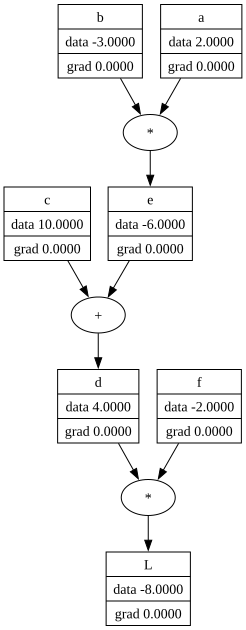

In [9]:
from graphviz import Digraph

def trace(root):
    # build a set of all nodes and edges in a graph
    nodes, edges = set() , set ()
    def build(v):
        if v not in nodes :
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


def draw_dot(root):
    dot = Digraph(format='svg' , graph_attr={'randir' : 'LR'}) # Left to Right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # For any value in the graph create a rect node 
        dot.node(name = uid , label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad) , shape='record')
        if n._op:
            # if this value is result of some operation, create an op node
            dot.node(name = uid +n._op , label=n._op)
            dot.edge(uid + n._op ,uid) # connect this node to it
    for n1,n2 in edges:
        # connect n1 to n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

draw_dot(L)

### Assigning Grad Values or Derivatives Value

Formula:
    $$
    Derivative f(x) = \frac{(f(x+h) - f(x))}{h} 
    $$
      where h is in limit
> Chain rule for getting back propagation derivative
$$
 \frac{DL}{DC} = \frac{DL}{DD} * \frac{DD}{DC}

$$

In [10]:
# Assigning derivatives
# L is directly proportional to L => 1
L.grad = 1.0

# dl / dd  => f (do formula (f(x+h) - f(x))/h  x = d * f ) => -2.0
d.grad = f.data
f.grad = d.data  # Vice versa for d

# chain rule
# dl/dc = dl/dd * dd/dc => Since addition it is c + e => 1.0
c.grad = d.grad * 1.0
e.grad = d.grad * 1.0

# chain rule for a and b
# since e = a * b ->
a.grad = e.grad * b.data
b.grad = e.grad * a.data

### Neural Network Neuron: 
![Alt text](https://cs231n.github.io/assets/nn1/neuron_model.jpeg)

In [11]:
# Inputs
x1 = Value(2.0, label='x1')
x2 =Value(0.0, label='x2')
# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# x1w1 & x2w2 as shown in image
x1w1 = x1 * w1; x1w1.label='x1 * w1'
x2w2 = x2 * w2; x2w2.label ='x2 * w2'
# b is bias of neuron
b = Value(6.88137, label='b')
# Cell body
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# Activation function here is tanh
o = n.tanh() ; o.label = 'o'
o


Value:(data = 0.7071049876722272)

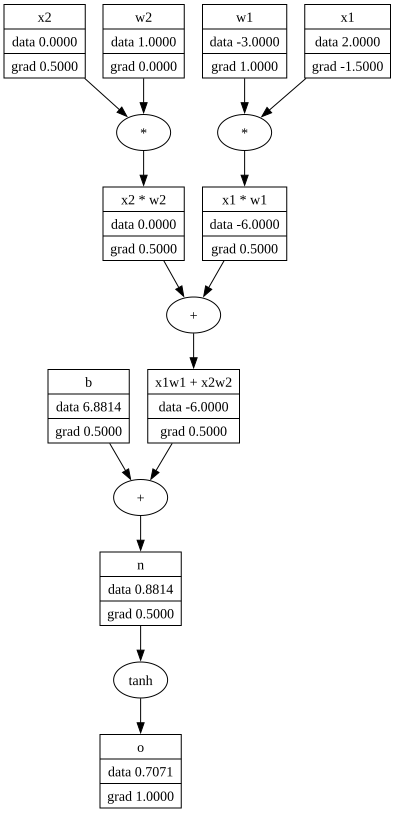

In [12]:
o.backward()
draw_dot(o)

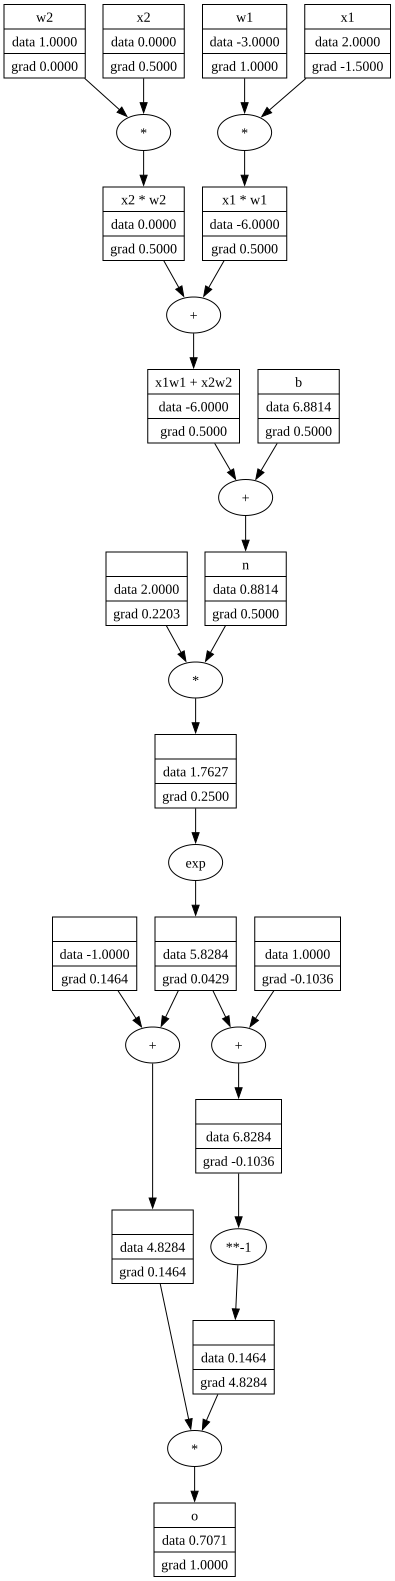

In [13]:
# splitting tanh into equation
# Inputs
x1 = Value(2.0, label='x1')
x2 =Value(0.0, label='x2')
# Weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# x1w1 & x2w2 as shown in image
x1w1 = x1 * w1; x1w1.label='x1 * w1'
x2w2 = x2 * w2; x2w2.label ='x2 * w2'
# b is bias of neuron
b = Value(6.88137, label='b')
# Cell body
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# Activation function here is tanh
e = (n*2).exp()
o = (e-1) / (e+1) ; o.label = 'o'
o.backward()
draw_dot(o)

## In Production we Use Pytorch

In [14]:
import torch

# Inputs
x1 = torch.tensor(2.0, requires_grad=True)
x2 = torch.tensor(0.0, requires_grad=True)

# Weights
w1 = torch.tensor(-3.0, requires_grad=True)
w2 = torch.tensor(1.0, requires_grad=True)

# x1w1 and x2w2
x1w1 = x1 * w1
x2w2 = x2 * w2

# Bias
b = torch.tensor(6.88137, requires_grad=True)

# Cell body
x1w1x2w2 = x1w1 + x2w2
n = x1w1x2w2 + b

# Activation function: tanh
o = torch.tanh(n)

print("x1w1 =", x1w1.item())
print("x2w2 =", x2w2.item())
print("n    =", n.item())
print("o    =", o.item())
o.backward()
print("grad x1 , x2, w1, w2", x1.grad.item() , x2.grad.item() , w1.grad.item() , w2.grad.item())

x1w1 = -6.0
x2w2 = 0.0
n    = 0.8813700675964355
o    = 0.7071050405502319
grad x1 , x2, w1, w2 -1.5000075101852417 0.5000025033950806 1.0000050067901611 0.0


### Making Multilayer Neuron
![ALT_TEXT](Assets/mlp.jpg)

In [15]:
class Neuron:
    def __init__(self,nin):  # Takes in value of how many x inputs are there
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]  # creates a tuple for random weights -1 , 1 for range on x inputs xi = wi
        self.b = Value(random.uniform(-1,1)) # Creates a bias random between -1,1
    def __call__(self,x):
        act = sum((wi * xi for wi , xi in zip(self.w,x)), self.b) # Activation functions Sigma(i) on wixi + b
        out = act.tanh() # TanH the activation function
        return out
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self,nin , nout): # Adding layer (increases number of neurons) nin = x inputs nout = Number.of neurons
        self.neurons = [Neuron(nin) for _ in range(nout)] # Takes the input size and nout to create z number of neurons
    def __call__(self,x):
        outs = [n(x) for n in self.neurons] # z number of neurons should have z number of outputs if nout 3 -> outs will be 3
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP: # this class inter connects Layers of neurons to depend on each other like we see in the above diagram.
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

x = [2.0 , 3.0 , -1.0]
n = MLP(len(x) , [4,4,2,1])
output = n(x)
output
        

Value:(data = -0.7303225862240061)

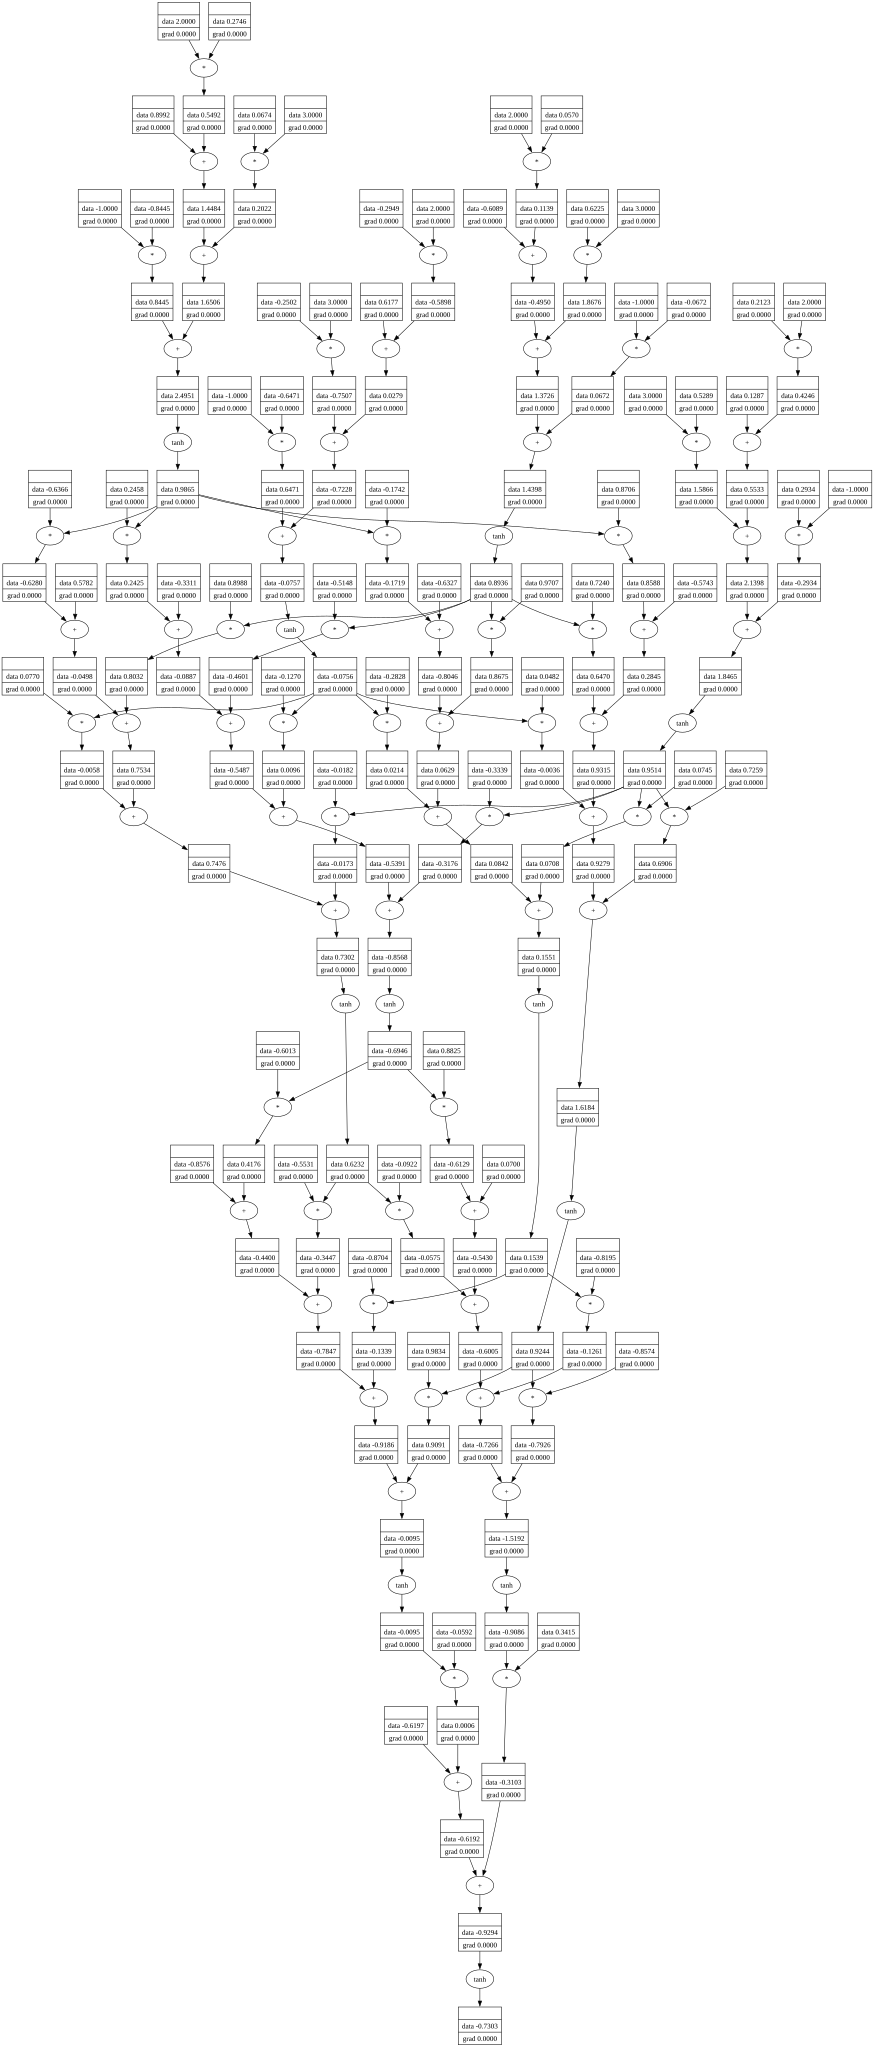

In [16]:
draw_dot(output)

In [17]:
xs = [
    [2.0, 3.0 , -1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]

ys = [1.0,-1.0,-1.0,1.0] #desired targets

In [18]:
# checking weight of w[0]
n.layers[0].neurons[0].w[0].grad

0.0

In [ ]:
# Loss function:
episodes = 20
for eps in range(episodes):
    # forward
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys,ypred))
    # backward propagation
    for p in n.parameters(): # very imp to reset grad to 0.0 before next episode or batch
        p.grad = 0.0
    loss.backward()
    # update
    for p in n.parameters():
        p.data += -0.1 * p.grad
    print(eps,loss.data)

0 6.309074081637496
1 4.732118213000038
2 3.2595831398476287
3 1.7689001356767537
4 0.06605431961784744
5 0.0020194992727385085
6 0.00012137882456386336
7 0.3184841248763137
8 1.2403023591495512
9 3.5091761209826195e-08
10 1.1185377272238327e-09
11 3.8479382053347687e-11
12 2.4310024598553056e-10
13 1.1228032511029425e-09
14 3.872743671898808e-10
15 2.502099672824334e-11
16 5.174704246507745e-13
17 7.528069828216721e-15
18 1.2952492498657335e-16
19 3.1760186819495538e-18


In [20]:
ypred

[Value:(data = 0.9999999987397358),
 Value:(data = -0.9999999999940973),
 Value:(data = -0.9999999999940973),
 Value:(data = 0.999999998739967)]